# DefectSignal: Prioritizing Urgent Product Complaints in Consumer Tech Reviews

**Business Analytics Case Study** | Srihitha Thotakura | CB.SC.U4CSE23450 | CSE-E

## Section 3: Data Preparation and Exploratory Analysis


| Part | What it does |
|---|---|
| 3.1 - 3.2 | Load the raw data and check its quality |
| 3.3 | Clean the data (with a log of every step) |
| 3.4 | Exploratory analysis before labeling |
| 3.5 | Create the **Urgent / Non-Urgent** label with transparent rules |
| 3.6 | Build a hand-labeled gold sample to check label quality |
| 3.7 | Text preprocessing for the classifier |
| 3.8 | Exploratory analysis of the labeled data |
| 3.9 | Train / test split and export of the final dataset |

In [1]:
import html
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, cohen_kappa_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

SEED = 42
C_FLIP, C_PLAY = "#4C78A8", "#F58518" 

In [2]:
# ---- Locate files (works in VS Code and on Kaggle) ----
IN_KAGGLE = Path("/kaggle/working").exists()


def find_file(name, extra_dirs=()):
    """Look for a file in the usual places: repo folders, current folder, Kaggle inputs."""
    cwd = Path.cwd()
    places = [cwd, cwd / "data" / "raw", cwd.parent / "data" / "raw",
              cwd / "data" / "labeling", cwd.parent / "data" / "labeling", *map(Path, extra_dirs)]
    for p in places:
        if (p / name).exists():
            return p / name
    if Path("/kaggle/input").exists():
        hits = sorted(Path("/kaggle/input").glob(f"**/{name}"))
        if hits:
            return hits[0]
    return None


RAW = find_file("reviews_raw.csv")
if RAW is None:
    raise FileNotFoundError("reviews_raw.csv not found. Put it in data/raw/ (VS Code) or upload it as a Kaggle dataset.")

if IN_KAGGLE:
    ROOT = Path("/kaggle/working")
elif RAW.parent.name == "raw" and RAW.parent.parent.name == "data":
    ROOT = RAW.parent.parent.parent
else:
    ROOT = Path.cwd()

CLEAN_DIR = ROOT / "data" / "clean"
LABEL_DIR = ROOT / "data" / "labeling"
FIG_DIR = ROOT / "figures"
for p in (CLEAN_DIR, LABEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

print("Raw data :", RAW)
print("Outputs  :", ROOT)

Raw data : c:\Users\saiva\Downloads\DefectSignal_Submission\data\raw\reviews_raw.csv
Outputs  : c:\Users\saiva\Downloads\DefectSignal_Submission


## 3.1 Load the raw data

The raw file combines two scraped sources: Google Play Store reviews of companion apps (`source_type = app`) and Flipkart product reviews (`source_type = product`). Reviewer names, locations and profile links were never stored.

In [3]:
# keep_default_na=False so that a review that literally says "None" or "NA" is not treated as missing
raw = pd.read_csv(RAW, keep_default_na=False, na_values=[""])
raw["review_text"] = raw["review_text"].fillna("").astype(str)
print("Raw records:", f"{len(raw):,}")
raw.head()

Raw records: 16,768


,review_text,review_title,rating,review_date,date_approx,platform_source,product_category,brand,product_name,source_type,helpful_votes,certified_buyer,app_id
0,"Buggy app, I bought a brand new Ultima Prime, but once I am pairing my device with the app, the wakeup ges...",NaN,1,2026-09-21,False,Google Play Store,smartwatch,boAt,boAt companion app,app,0,NaN,com.coveiot.android.boat
1,super experience and valuable and helpful in daily routine,NaN,5,2026-09-20,False,Google Play Store,smartwatch,boAt,boAt companion app,app,0,NaN,com.coveiot.android.boat
2,Good,NaN,5,2026-09-20,False,Google Play Store,smartwatch,boAt,boAt companion app,app,0,NaN,com.coveiot.android.boat
3,super 😍,NaN,5,2026-09-20,False,Google Play Store,smartwatch,boAt,boAt companion app,app,0,NaN,com.coveiot.android.boat
4,wonder full,NaN,5,2026-09-20,False,Google Play Store,smartwatch,boAt,boAt companion app,app,0,NaN,com.coveiot.android.boat


## 3.2 Data quality checks

Before cleaning, we measure the problems that would distort a text classifier: missing values, very short reviews, duplicate texts and formatting noise.

In [4]:
quality = pd.DataFrame({"missing_values": raw.isna().sum(), "dtype": raw.dtypes.astype(str)})
quality

,missing_values,dtype
review_text,0,object
review_title,14336,object
rating,0,int64
review_date,0,object
date_approx,0,bool
platform_source,0,object
product_category,0,object
brand,0,object
product_name,0,object
source_type,0,object


In [5]:
raw["word_count"] = raw["review_text"].str.split().str.len()
lower_text = raw["review_text"].str.lower().str.strip()
html_entities = raw["review_text"].str.contains(r"&\w+;|&#\d+;").sum()
line_breaks = raw["review_text"].str.contains("\n").sum()

print(f"Reviews with 1-2 words:            {(raw['word_count'] <= 2).mean():.1%}")
print(f"Exact duplicate texts:             {lower_text.duplicated().mean():.1%}")
print(f"Texts containing HTML entities:    {html_entities}")
print(f"Texts containing line breaks:      {line_breaks}")
print()
print("Most repeated review texts:")
print(lower_text.value_counts().head(8))
print()
print("Words per review by source:")
raw.groupby("platform_source")["word_count"].describe().round(1)

Reviews with 1-2 words:            27.3%
Exact duplicate texts:             21.7%
Texts containing HTML entities:    23
Texts containing line breaks:      180

Most repeated review texts:
review_text
good         989
nice         376
very good    153
super        129
good 👍       120
ok           102
excellent    101
best          95
Name: count, dtype: int64

Words per review by source:


,count,mean,std,min,25%,50%,75%,max
platform_source,,,,,,,,
Flipkart,2432.0,9.5,18.9,1.0,2.0,4.0,9.0,389.0
Google Play Store,14336.0,29.5,30.2,1.0,2.0,17.0,53.0,181.0


**Interpretation.** Flipkart reviews are much shorter than Google Play reviews. About a quarter of all reviews have only one or two words, and about a fifth of the texts are exact duplicates, mostly generic praise such as "good" or "nice". Duplicates matter because the same text could land in both the training and the test set and inflate the reported accuracy. A few texts also contain HTML entities and line breaks that must be normalised.

## 3.3 Data cleaning

Each step is logged so the report can show exactly how many records each rule removed.

| Step | Rule | Reason |
|---|---|---|
| 1 | Decode HTML entities, collapse whitespace, mask phone numbers, e-mails and URLs | Consistent text; removes any personal details typed inside reviews |
| 2 | Drop reviews with no letters (emoji or symbols only) | No text to classify |
| 3 | Drop reviews written mostly in non-Latin scripts | Scope is English-language reviews |
| 4 | Drop reviews mostly in an Indian language written in English letters (Hindi, Telugu, Kannada, Tamil, Malayalam, Marathi, Bengali) | Word features are English-only |
| 5 | Drop exact duplicate texts (ignoring case, punctuation and emoji) | Prevents train/test leakage and repeated noise |

Short reviews (1-2 words) are **kept**: a real triage tool receives them, and they are valid Non-Urgent examples.

In [6]:
# Common words from several Indian languages, written in English letters ("Hindi/Telugu/etc.
# in Latin script"). Reviews made mostly of these words are dropped, since the keyword and TF-IDF
# features used later are English-only.
INDIC_WORDS = {
    # Hindi / Urdu
    "nahi", "nahin", "nhi", "bahut", "bahot", "bhut", "bht", "accha", "acha", "achha", "achcha",
    "bekar", "bakwas", "paisa", "paise", "kharab", "mera", "meri", "mujhe", "bhai", "ekdum",
    "bilkul", "zyada", "jyada", "wala", "wali", "gaya", "gayi", "kya", "liye", "bhi", "hai",
    "hain", "raha", "rahi", "karta", "mein", "madat", "laga", "kro", "pese", "thik", "sahi", "galat",
    # Telugu
    "bagundi", "bagundhi", "bagundhu", "bagoledu", "manchi", "manchidi", "chala", "bavundi",
    "bavuledu", "superga", "vundi", "ledu", "undi", "chesindi", "teliyadu", "kastam", "bagaledu",
    # Kannada
    "chennagide", "chennagilla", "sooper", "channagi", "bahala", "kelasa", "kelvi", "illa", "ide",
    "tumba", "tombha",
    # Tamil
    "romba", "nalla", "nallairukku", "semma", "iruku", "illai", "theriyala", "seri", "kammiya",
    # Malayalam
    "nallath", "kollam", "ariyilla", "undu",
    # Marathi
    "changla", "changle", "zhala", "barobar", "mast", "masst",
    # Bengali
    "bhalo", "kharap", "hoyni", "hocche",
}
PHONE = re.compile(r"(?<!\d)(?:\+?91[\s-]?)?[6-9]\d{9}(?!\d)")
EMAIL = re.compile(r"[\w.+-]+@[\w-]+\.[\w.]+")
URL = re.compile(r"https?://\S+|www\.\S+")


def normalize(text):
    text = html.unescape(text)
    return re.sub(r"\s+", " ", text).strip()


def mask_pii(text):
    text = EMAIL.sub("<EMAIL>", text)
    text = URL.sub("<URL>", text)
    return PHONE.sub("<PHONE>", text)


def has_letters(text):
    return any(ch.isalpha() for ch in text)


def non_latin_share(text):
    letters = [ch for ch in text if ch.isalpha()]
    return sum(ord(ch) > 127 for ch in letters) / len(letters) if letters else 0.0


def indic_share(text):
    words = re.findall(r"[a-z']+", text.lower())
    return sum(w in INDIC_WORDS for w in words) / len(words) if words else 0.0

In [7]:
df = raw.drop(columns=["word_count"]).copy()
log = [("Raw records", len(df), 0)]


def record(step, before):
    log.append((step, len(df), before - len(df)))


# Step 1: normalise text and mask personal details
df["review_text"] = df["review_text"].map(normalize).map(mask_pii)

# Step 2: no letters
n = len(df)
df = df[df["review_text"].map(has_letters)]
record("Remove reviews with no letters (emoji/symbols only)", n)

# Step 3: non-Latin scripts
n = len(df)
df = df[df["review_text"].map(non_latin_share) <= 0.5]
record("Remove non-Latin-script reviews", n)

# Step 4: mostly a non-English Indian language written in English letters
n = len(df)
df = df[df["review_text"].map(indic_share) < 0.2]
record("Remove reviews mostly in an Indian language (Latin script)", n)

# Step 5: exact duplicates (ignoring case and punctuation/emoji).
# Flipkart rows sort first, so a text that appears on both sources is kept on the smaller source.
n = len(df)
key = df["review_text"].str.lower().str.replace(r"[^\w\s]", "", regex=True).str.strip()
df = df.assign(_key=key).sort_values("platform_source", kind="stable")
df = df.drop_duplicates("_key", keep="first").drop(columns="_key")
record("Remove exact duplicate texts", n)

cleaning_log = pd.DataFrame(log, columns=["step", "records_remaining", "records_removed"])
cleaning_log

,step,records_remaining,records_removed
0,Raw records,16768,0
1,Remove reviews with no letters (emoji/symbols only),16589,179
2,Remove non-Latin-script reviews,16536,53
3,Remove reviews mostly in an Indian language (Latin script),16431,105
4,Remove exact duplicate texts,12449,3982


In [8]:
# Final features and export of the cleaned data
df["review_date"] = pd.to_datetime(df["review_date"])
df["word_count"] = df["review_text"].str.split().str.len()
df["char_count"] = df["review_text"].str.len()
df = df.sort_values(["platform_source", "product_category", "review_date", "review_text"]).reset_index(drop=True)
df.insert(0, "review_id", np.arange(1, len(df) + 1))

keep = ["review_id", "review_text", "review_title", "rating", "review_date", "date_approx",
        "platform_source", "source_type", "product_category", "brand", "product_name",
        "helpful_votes", "certified_buyer", "word_count", "char_count"]
clean = df[keep].copy()
clean.to_csv(CLEAN_DIR / "reviews_clean.csv", index=False, encoding="utf-8")

assert len(clean) >= 10_000, "Dataset fell below the 10,000-record requirement"
print(f"Clean records: {len(clean):,}  (kept {len(clean) / len(raw):.1%} of {len(raw):,} raw records)")
print("Saved to:", CLEAN_DIR / "reviews_clean.csv")

Clean records: 12,449  (kept 74.2% of 16,768 raw records)
Saved to: c:\Users\saiva\Downloads\DefectSignal_Submission\data\clean\reviews_clean.csv


## 3.4 Exploratory analysis (before labeling)

In [9]:
by_source = clean.groupby("platform_source").agg(
    reviews=("review_id", "count"), avg_rating=("rating", "mean"), median_words=("word_count", "median")
).round(2)
by_category = clean.groupby(["platform_source", "product_category"]).agg(
    reviews=("review_id", "count"), avg_rating=("rating", "mean"), median_words=("word_count", "median")
).round(2)
print(by_source, "\n")
by_category

                   reviews  avg_rating  median_words
platform_source                                     
Flipkart              1620        3.59           6.0
Google Play Store    10829        2.74          33.0 



reviews  avg_rating  median_words
platform_source   product_category                                   
Flipkart          earbuds               455        3.67           6.0
                  power_bank            775        3.55           7.0
                  smartwatch            390        3.57           6.0
Google Play Store earbuds              2208        2.45          19.0
                  smartwatch           6654        2.95          40.0
                  wearable_mixed       1967        2.34          47.0

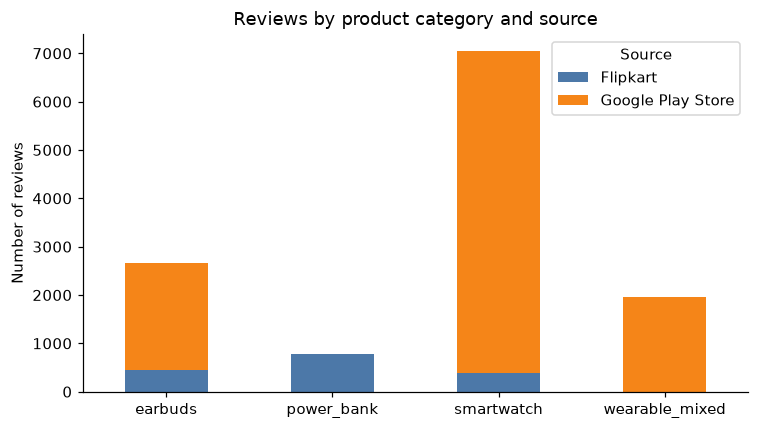

In [10]:
# Figure 1: dataset composition
comp = clean.groupby(["product_category", "platform_source"]).size().unstack(fill_value=0)
ax = comp.plot(kind="bar", stacked=True, figsize=(7, 4), color=[C_FLIP, C_PLAY])
ax.set_title("Reviews by product category and source")
ax.set_xlabel("")
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_composition.png")
plt.show()

**Figure 1.** Google Play supplies about 87% of the cleaned reviews and Flipkart about 13%. Smartwatch is the largest category. Power banks come only from Flipkart and make up roughly 6% of the data, so any conclusion about power banks rests on a smaller sample. The source is therefore kept as a variable throughout the analysis.

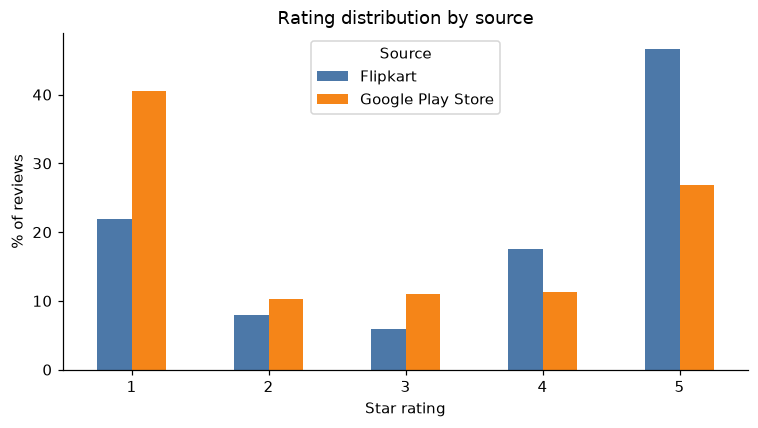

In [11]:
# Figure 2: rating distribution by source (share of each source's reviews)
ratings = pd.crosstab(clean["rating"], clean["platform_source"], normalize="columns") * 100
ax = ratings.plot(kind="bar", figsize=(7, 4), color=[C_FLIP, C_PLAY])
ax.set_title("Rating distribution by source")
ax.set_xlabel("Star rating")
ax.set_ylabel("% of reviews")
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_ratings.png")
plt.show()

**Figure 2.** Ratings are polarised: most reviews are 1-star or 5-star and few sit in the middle. Google Play is clearly more negative (about 40% one-star, against about 22% on Flipkart). App reviews therefore contain more complaints, but not every complaint is about a defect: many are about pricing, features or the user interface. Separating the two is exactly what the Urgent label is for.

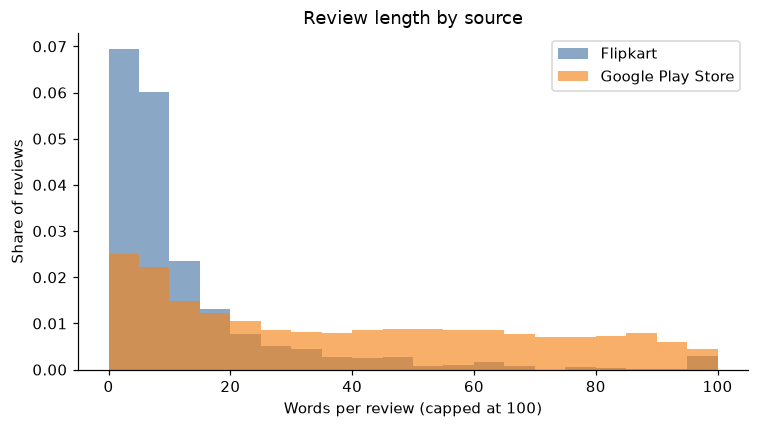

In [12]:
# Figure 3: review length by source (capped at 100 words for readability)
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, 105, 5)
for source, colour in zip(["Flipkart", "Google Play Store"], [C_FLIP, C_PLAY]):
    words = clean.loc[clean["platform_source"] == source, "word_count"].clip(upper=100)
    ax.hist(words, bins=bins, alpha=0.65, density=True, label=source, color=colour)
ax.set_title("Review length by source")
ax.set_xlabel("Words per review (capped at 100)")
ax.set_ylabel("Share of reviews")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_length.png")
plt.show()

**Figure 3.** Flipkart reviews are short (median about 6 words) while Google Play reviews are much longer (median about 33 words). Short reviews carry little text signal, so a classifier is expected to perform differently on the two sources. Model results are therefore reported per source as well as overall.

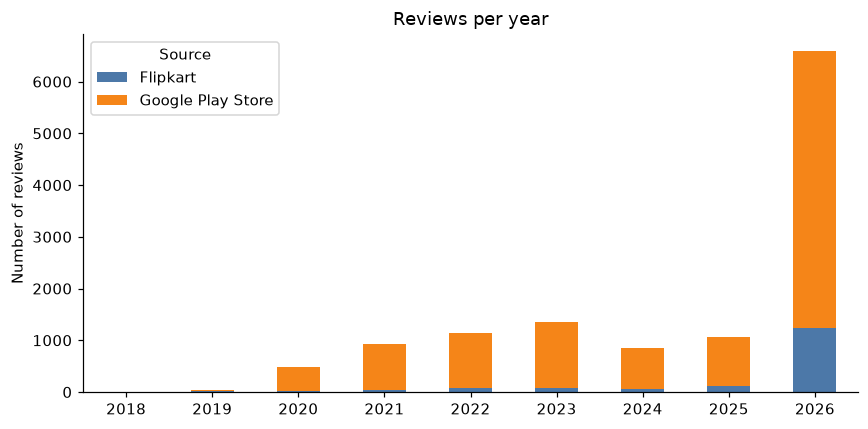

In [13]:
# Figure 4: reviews per year (Flipkart dates are approximate: "3 months ago" style)
per_year = clean.groupby([clean["review_date"].dt.year, "platform_source"]).size().unstack(fill_value=0)
ax = per_year.plot(kind="bar", stacked=True, figsize=(8, 4), color=[C_FLIP, C_PLAY])
ax.set_title("Reviews per year")
ax.set_xlabel("")
ax.set_ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_years.png")
plt.show()

**Figure 4.** Most reviews are from 2026 because the "newest" sort order favours recent reviews; older reviews come from the "most relevant" and "most helpful" orders. Flipkart shows relative dates ("3 months ago"), so its dates are approximate and no fine-grained time-trend analysis is attempted.

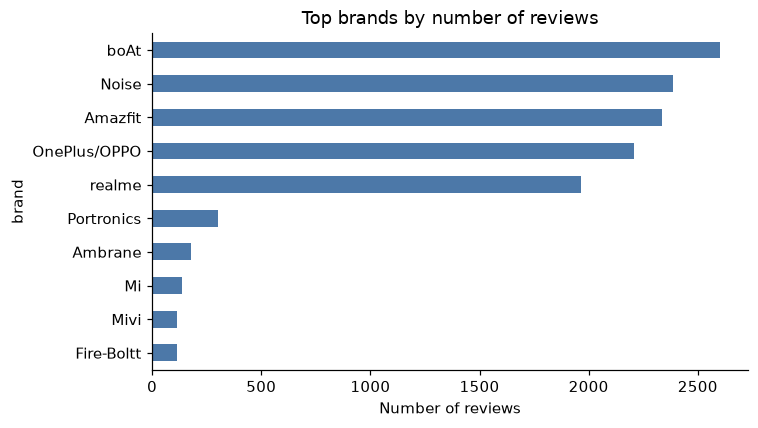

In [14]:
# Figure 5: brands
top_brands = clean["brand"].value_counts().head(10).sort_values()
ax = top_brands.plot(kind="barh", figsize=(7, 4), color=C_FLIP)
ax.set_title("Top brands by number of reviews")
ax.set_xlabel("Number of reviews")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_brands.png")
plt.show()

**Figure 5.** The five brands whose companion apps were scraped (boAt, Noise, Amazfit, OnePlus/OPPO, realme) account for most of the reviews. Brands that appear only on Flipkart, such as Portronics, Ambrane, Mi, Mivi and Fire-Boltt, each contribute a few hundred reviews at most, so brand-level comparisons are only reliable for the larger brands.

## 3.5 Creating the Urgent / Non-Urgent label

The scraped reviews have no urgency label, so one must be created. With more than 12,000 reviews, hand-labeling everything is not realistic. The approach has two stages:

1. **Rule-based labels for every review** (this section). Transparent keyword rules, described below.
2. **A hand-labeled gold sample** (Section 3.6). A random sample labeled by a human, used to measure how good the rules are and later to evaluate the model honestly.

### Codebook

| | Definition |
|---|---|
| **Urgent** | (a) a **safety hazard**: overheating, swelling, burning, smoke, sparks, electric shock; (b) a **failure that stops normal use**: will not charge, connect, sync, turn on or log in, has stopped working, is defective or arrived damaged; (c) a **refund, replacement, warranty or fraud** demand or claim |
| **Non-Urgent** | praise; vague negativity with no specifics ("bad", "worst"); feature requests, user-interface or paywall complaints; minor cosmetic issues; problems the reviewer says were already resolved |

Gray area: app problems such as "cannot log in" or "device not getting added" count as **Urgent** when they stop the device from being used, and as Non-Urgent when they are only an inconvenience.

### How the rules work

- **Strong rules** (safety words; "stopped working", "dead on arrival", "not charging", "defective") mark a review Urgent regardless of rating.
- **Gated rules** (refund/fraud words, generic "not working", app connection and login failures, battery failure, hardware defects, support complaints) mark a review Urgent only when the rating is 3 stars or lower. This removes many false matches from happy reviews that mention a problem in passing.
- **Negation and context filters** remove phrases that look like problems but are not: "no issues", "does not heat up", "calories burned", "great replacement".
- **Resolved problems**: if a review of 4 stars or more says the issue was "resolved" or "fixed", it is not marked Urgent.

The rating is used *only to create the label*. It is **not** a feature of the classifier in Section 4, so the model has to learn from the review text alone.

In [15]:
import re, html
import pandas as pd

def match_text(t):
    t = html.unescape(str(t)).lower().replace("’", "'").replace("`", "'")
    for pat, rep in [(r"\bwon'?t\b", "will not"), (r"\bcan'?t\b", "can not"), (r"\bcannot\b", "can not"),
                     (r"\bain'?t\b", "is not"),
                     (r"\b(dont|doesnt|isnt|wasnt|werent|hasnt|havent|hadnt|couldnt|wouldnt|shouldnt)\b",
                      lambda m: {"dont":"do not","doesnt":"does not","isnt":"is not","wasnt":"was not","werent":"were not",
                                 "hasnt":"has not","havent":"have not","hadnt":"had not","couldnt":"could not",
                                 "wouldnt":"would not","shouldnt":"should not"}[m.group(1)]),
                     (r"n't\b", " not")]:
        t = re.sub(pat, rep, t)
    return re.sub(r"\s+", " ", t).strip()

NEUTRAL = re.compile("|".join([
    r"\b(?:no|zero|without(?: any)?|never (?:had|faced|got|seen|experienced)(?: any)?|not (?:a )?single|did not (?:face|have|get)(?: any)?|do not (?:have|face)(?: any)?|have not (?:had|faced)(?: any)?)\s+(?:\w+\s+){0,2}(?:issues?|problems?|complaints?|complain\w*|defects?|heating|overheating|lag|glitch(?:es)?|trouble)",
    r"\b(?:(?:does|did|do|will|would|can|could|is|are|was|were)\s+)?(?:not|never)\s+(?:get(?:ting|s)?\s+|become\s+|becomes\s+)?(?:over\s?)?(?:heat\w*|hot)(?:\s*up)?",
    r"\b(?:great|good|perfect|best|better|worthy|nice|decent|excellent|ideal|worthwhile)\s+replacement|as a replacement|replacement (?:for|of) (?:my|the) (?:old|previous|earlier)",
    r"\bcalou?ries?\s+burn\w*|\bburn(?:ed|t|s|ing)?\s+(?:the\s+|more\s+|my\s+)?(?:calou?ries?|fat)|\bfat\s+burn\w*|\bcalories? burned",
    r"\bshocked (?:to|by|at|with)|\bshocking (?:price|quality|sound|bass)",
]))

SAFETY = re.compile("|".join([
    r"over\s?heat\w*", r"heating (?:issue|problem|up)", r"heats? up", r"heated up",
    r"(?:getting|gets|get|got|becomes|became) (?:very |too |extremely |so |really )?(?:hot|heated)", r"too hot", r"very hot", r"extremely hot", r"burning hot",
    r"burn(?:t|ed)? (?:smell|my|out|down)", r"burning (?:smell|smoke)", r"smell(?:s|ed)? (?:of )?(?:burn\w*|smoke|plastic)",
    r"\bsmok(?:e|ing|ed)\b", r"caught fire", r"catch(?:es|ing)? fire", r"on fire", r"fire hazard", r"short[- ]?circuit\w*",
    r"\bsparks? (?:came|coming|from|flew)|\bsparking\b",
    r"swell(?:ed|ing|s)?", r"swollen", r"\bbulg(?:e|ed|ing)\b", r"puffed up", r"\bballoon(?:ed)?\b",
    r"explo(?:de|ded|sion|ding)", r"blew up", r"(?:battery|power ?bank|charger) (?:burst|blast)",
    r"electric(?:al)? shock", r"got (?:an? )?shock", r"shock(?:s|ed)? me", r"current (?:leak|shock)",
    r"\bmelt(?:ed|ing|s)?\b", r"\bfumes?\b",
]))

STRONG = {
 "malfunction": re.compile("|".join([
    r"stop(?:ped|s)? working", r"stop(?:ped|s)? (?:charging|responding|connecting|syncing|functioning|turning on)",
    r"dead on arrival", r"\bdoa\b", r"(?:went|gone|became|completely|totally|fully|already) dead", r"(?:died|dead) (?:after|within|in|on)",
    r"(?:is|are|was|were|will|would|does|did|do|can|could) not (?:able to )?(?:turn|switch|power|start)(?:ed|ing)? on",
    r"not (?:getting )?(?:charged|charging)", r"(?:will|would|does|did|do|can|could) not (?:get )?charg\w*",
    r"charging (?:issue|problem)s?", r"not holding (?:a )?charge", r"fail(?:s|ed)? to charge (?:the |my )?(?:phone|device|mobile)", r"unable to charge (?:the |my )?(?:phone|device|mobile)",
    r"(?:does|did|do) not work at all", r"not working at all", r"not working (?:after|within|properly|since)",
    r"(?:only )?work(?:ed|s)? (?:for )?(?:only |just )(?:a |an |one |two |three |\d+ |few )?(?:day|days|week|weeks|month|months|hour|hours|minute|minutes)",
    r"\bdefective\b", r"\bfaulty\b", r"manufactur\w+ (?:defect|fault)",
    r"(?:received|got|delivered|arrived|came) (?:a |an |the |with )?(?:damaged|broken|defective|faulty|dead|used|old|open|cracked|tampered)",
    r"(?:damaged|broken|cracked) (?:on arrival|product|item|piece|unit|screen|display)",
    r"(?:one|left|right) (?:side|ear ?bud|earphone|bud|earpiece) (?:is |has )?(?:not working|stopped|dead|not playing|no sound)",
 ])),
}

GATED = {
 "refund_fraud": re.compile("|".join([
    r"\brefund\w*", r"money back", r"\breplacement\b", r"replace (?:it|this|my|the|them)", r"warranty (?:claim|issue|void|denied|period|not)|claim(?:ed|ing)? (?:the |my )?warranty|under warranty",
    r"(?:want|need|going|plan(?:ning)?|decided|had|have|trying) to return", r"return(?:ed|ing)? (?:it|this|them|the (?:product|watch|band|item|power ?bank|buds|earbuds)|my (?:watch|band|order|product|item|earbuds|buds|power ?bank|money))", r"return my money", r"please (?:return|refund|replace)",
    r"\bfraud\w*", r"\bscam\w*", r"\bcheat(?:ed|ing|ers?)?\b", r"\bfake (?:product|item|watch|earbuds?|power ?bank|one|battery)",
    r"not genuine", r"\bcounterfeit\b", r"duplicate (?:product|item|piece|one)", r"not original",
 ])),
 "not_working": re.compile("|".join([
    r"(?:does|did|do|is|are|was|were) not work\b", r"not working", r"not functioning", r"not function\b", r"no longer work\w*",
 ])),
 "app_connectivity": re.compile("|".join([
    r"(?:not|unable to|can not|could not|will not|fail(?:s|ed)? to) (?:able to )?(?:connect|pair|sync|log ?in|sign ?in|register|detect)",
    r"(?:not|unable to|can not|could not|will not) (?:able to )?(?:find|add|see|detect) (?:the |my |any )?(?:device|watch|band|buds|earbuds|headset|earphones?)",
    r"(?:connection|connectivity|bluetooth|sync|syncing|pairing|login|log in|otp) (?:issue|problem|error|failed|failure|drop)s?",
    r"otp (?:is )?not (?:coming|received|working|arriving)", r"(?:keeps?|keep) disconnecting", r"get(?:s|ting)? disconnected",
    r"disconnect(?:s|ed|ing)? (?:again|frequently|often|every|randomly|automatically)", r"not (?:connecting|syncing|pairing|responding|detecting)",
    r"(?:will not|won'?t|does not|refuses to) reconnect", r"unpair(?:s|ed|ing)? (?:itself|automatically|again|by (?:itself|evening|morning))?",
    r"unable to (?:switch|change|select|adjust|use) (?:the )?(?:equalizer|eq\b)",
    r"(?:app )?(?:keeps? )?crash(?:es|ing|ed)?\b", r"force close", r"stuck (?:on|at) (?:loading|logo|boot|update|updating|pairing|connecting|syncing)",
    r"\bhang(?:s|ing)?\b", r"\bfreez(?:e|es|ing)\b",
    r"will not let me (?:\w+ )?(?:log ?in|sign ?in|connect|pair|register)",
    r"not receiving (?:the |any |my )?otp", r"(?:do|does|did) not (?:receive|get) (?:the |any |an |my )?otp",
    r"(?:problem|issue)s? (?:that )?(?:i(?: a|')?m facing )?(?:(?:is|of|with|in) )*(?:the )?(?:syncing|sync\b|connecting|pairing|log ?in)",
    r"clos(?:es|ing) (?:every time|automatically|by itself|itself|on its own|suddenly)",
    r"(?:difficult|hard|trouble|struggl\w+|difficulty) (?:to |in |with )?(?:connect\w*|pair\w*|sync\w*|log ?in)",
 ])),
 "battery_failure": re.compile("|".join([
    r"battery (?:drain\w*|dies|died|is dead|issue|problem)", r"drains? (?:fast|quickly|very fast|so fast)",
    r"(?:only |just )(?:lasts?|last(?:ed|s)?|runs?|ran|work(?:s|ed)?) (?:for )?(?:around |about )?(?:\d+|an?|one|two|three|few) (?:min|mins|minute|minutes|hour|hours|hr|hrs)",
    r"battery (?:backup|life) (?:is )?(?:very |too |really )?(?:poor|bad|worst|terrible|pathetic)",
 ])),
 "hardware_defect": re.compile("|".join([
    r"\bno sound\b(?!\s+(?:equali|mode|eq\b|settings?|option|profile|effect))", r"sound (?:issue|problem)s?", r"(?:sound|voice|audio) (?:is )?not (?:coming|audible|clear)",
    r"\bmic(?:rophone)? (?:not|issue|problem)", r"(?:speaker|touch|screen|display|button|charging port|strap|glass) (?:not|issue|problem|broke|broken|cracked|stuck|dead|flicker\w*|blank)",
    r"call (?:quality )?(?:issue|problem)s?", r"calls? (?:keeps? )?(?:drop|dropping|disconnect\w*)",
 ])),
 "support_complaint": re.compile("|".join([
    r"\bno (?:any )?(?:response|reply|resolution|help)\b", r"\bno (?:customer |technical )?support\b", r"not (?:getting|received|receiving) (?:any )?(?:response|reply|resolution|help)", r"service cent(?:er|re)",
    r"(?:lodged|raised|filed|registered|logged) (?:a |an )?(?:complaint|ticket)", r"complaint (?:number|no\b|id)",
 ])),
}

RESOLVED = re.compile("|".join([
    r"\bresolved\b", r"\bsolved\b", r"\bfixed\b", r"sorted out", r"working (?:fine|well|great|perfectly|properly) now",
    r"replaced (?:it |the product |my )?(?:quickly|immediately|promptly|within)", r"(?:got|received) (?:a |my |the )?(?:refund|replacement)",
    r"refund(?:ed)? (?:was )?(?:quick|quickly|processed|received)", r"thanks? (?:to )?(?:the )?(?:customer|support|team)",
]))

def label_frame(df):
    mt = df["review_text"].map(match_text)
    nt = mt.map(lambda s: NEUTRAL.sub(" ", s))
    out = pd.DataFrame(index=df.index)
    out["hit_safety"] = nt.map(lambda s: bool(SAFETY.search(s)))
    for k, rx in STRONG.items(): out[f"hit_{k}"] = nt.map(lambda s, rx=rx: bool(rx.search(s)))
    for k, rx in GATED.items():  out[f"hit_{k}"] = nt.map(lambda s, rx=rx: bool(rx.search(s)))
    out["hit_resolved"] = mt.map(lambda s: bool(RESOLVED.search(s)))
    r = df["rating"]
    resolved_hi = out["hit_resolved"] & (r >= 4)
    eff = {"safety": out["hit_safety"]}
    for k in STRONG: eff[k] = out[f"hit_{k}"] & ~resolved_hi
    for k in GATED:  eff[k] = out[f"hit_{k}"] & (r <= 3) & ~out["hit_resolved"]
    order = ["safety","malfunction","refund_fraud","not_working","app_connectivity","battery_failure","hardware_defect","support_complaint"]
    eff_df = pd.DataFrame(eff)[order]
    out["weak_label"] = eff_df.any(axis=1).astype(int)
    out["rule_type"] = eff_df.idxmax(axis=1).where(eff_df.any(axis=1), "none")
    return out

In [16]:
labels = label_frame(clean)
for col in labels.columns:
    clean[col] = labels[col].values

print(f"Urgent (rule-based): {clean['weak_label'].mean():.1%} of {len(clean):,} reviews")
print()
print("Urgent share by source and category (%):")
print((clean.groupby(["platform_source", "product_category"])["weak_label"].mean() * 100).round(1).to_string())
print()
print("Urgent share by star rating (%):")
print((clean.groupby("rating")["weak_label"].mean() * 100).round(1).to_string())
print()
print("Which rule fired (Urgent reviews only):")
print(clean.loc[clean["weak_label"] == 1, "rule_type"].value_counts().to_string())

Urgent (rule-based): 21.9% of 12,449 reviews

Urgent share by source and category (%):
platform_source    product_category
Flipkart           earbuds              8.4
                   power_bank          11.0
                   smartwatch          12.3
Google Play Store  earbuds             19.9
                   smartwatch          22.0
                   wearable_mixed      33.5

Urgent share by star rating (%):
rating
1    42.9
2    32.0
3    20.3
4     1.3
5     0.5

Which rule fired (Urgent reviews only):
rule_type
app_connectivity     1469
not_working           555
malfunction           409
refund_fraud          159
support_complaint      62
hardware_defect        30
battery_failure        28
safety                 18


In [17]:
# Sanity check: read a few examples of each rule yourself. Are they really Urgent?
pd.set_option("display.max_colwidth", 200)
for rule in clean.loc[clean["weak_label"] == 1, "rule_type"].value_counts().index:
    sample = clean[(clean["rule_type"] == rule)].sample(4, random_state=SEED)
    print(f"\n=== {rule} ===")
    for _, r in sample.iterrows():
        print(f"  [{r['rating']} star] {r['review_text'][:170]}")


=== app_connectivity ===
  [2 star] I connected realme buds t310 but in app shows it doesn't connected and I can't control anything please fix this bug
  [2 star] i don't know why my oneplus nord buds 2r does not connect with this app any solution for it ?
  [2 star] I am using realme link app for my realme 2 Pro watch since last one month. I am facing sync problem everytime when I open the app. After outdoor running or walking, somet
  [1 star] Not able to connect my redmi note 4 phone... I have downloaded the software still not able to connect. Everytime they tell to restart the earphone

=== not_working ===
  [1 star] Hi Boat. I have purchased boat primia smartwatch and opened it with lot of enthusiasm and try to connect it through the app but the app is not at all detecting the watch 
  [1 star] does not work, show error can't connect internet
  [1 star] This app is not working for Oneplus buds Pro using OnePlus 6 device.
  [2 star] can we use this app for boat Xtend V16. As boat 

## 3.6 Hand-labeled gold sample

Rule-based labels are only *proxies*. If a model is trained and tested on the same rules, it just learns the rules back and its scores look better than they are. To avoid this, a random sample of reviews is **labeled by hand**, without seeing the rating or the rule result. This gold sample is used to:

1. measure how well the rules agree with human judgment (precision, recall, Cohen's kappa), and
2. evaluate the final model on labels that did not come from the rules.

The sample is **stratified** by source and product category (with a minimum of 60 reviews per group so small groups such as Flipkart power banks are still represented) and split into a **development part** (40%: use it to find and fix rule errors) and a **test part** (60%: never inspect it for errors; it gives the final honest numbers).

In [18]:
GOLD_N = 700            # size of the hand-labeled sample
MIN_PER_STRATUM = 60    # minimum reviews per source x category group

TO_LABEL = LABEL_DIR / "gold_sample_to_label.csv"
META = LABEL_DIR / "gold_meta.csv"

CODEBOOK_TEXT = """LABELING CODEBOOK - write U or N in the gold_label column

U = Urgent
  - a safety hazard (overheating, swelling, burning, smoke, sparks, electric shock)
  - a failure that stops normal use (will not charge / connect / sync / turn on / log in,
    stopped working, defective or arrived damaged)
  - a refund, replacement, warranty or fraud demand or claim

N = Non-Urgent
  - praise or neutral comments
  - vague negativity with no specifics ("bad", "worst", "waste")
  - feature requests, user-interface or paywall/price complaints
  - minor cosmetic issues
  - problems the reviewer says are already resolved

Judge the TEXT only. If a review contains both praise and a real failure, label U.
If unsure, choose N and write a short note in the notes column.
"""

if not TO_LABEL.exists():
    sizes = clean.groupby(["platform_source", "product_category"]).size()
    alloc = (sizes / sizes.sum() * GOLD_N).round().astype(int).clip(lower=MIN_PER_STRATUM)
    alloc = pd.concat([alloc, sizes], axis=1).min(axis=1)          # cannot exceed group size
    alloc.loc[alloc.idxmax()] += GOLD_N - alloc.sum()              # make the total exactly GOLD_N

    parts = []
    for (src, cat), k in alloc.items():
        pool = clean[(clean["platform_source"] == src) & (clean["product_category"] == cat)]
        parts.append(pool.sample(n=int(k), random_state=SEED))
    gold_pick = pd.concat(parts)
    gold_pick["stratum"] = gold_pick["platform_source"] + " | " + gold_pick["product_category"]
    gold_pick["gold_weight"] = [sizes[(s, c)] / alloc[(s, c)] for s, c in
                                zip(gold_pick["platform_source"], gold_pick["product_category"])]

    dev_ids, test_ids = train_test_split(gold_pick["review_id"].values, test_size=0.6,
                                         stratify=gold_pick["stratum"].values, random_state=SEED)
    gold_pick["gold_split"] = np.where(gold_pick["review_id"].isin(set(dev_ids)), "dev", "test")

    gold_pick[["review_id", "stratum", "gold_weight", "gold_split"]].to_csv(META, index=False)
    sheet = gold_pick.sample(frac=1, random_state=SEED)[["review_id", "review_text"]].copy()   # shuffled, blind
    sheet["gold_label"] = ""
    sheet["notes"] = ""
    sheet.to_csv(TO_LABEL, index=False, encoding="utf-8-sig")            # utf-8-sig so Excel shows emoji correctly
    (LABEL_DIR / "labeling_codebook.txt").write_text(CODEBOOK_TEXT, encoding="utf-8")
    print(f"Created the labeling sheet with {len(sheet)} reviews:\n  {TO_LABEL}")
else:
    print("Labeling sheet already exists - not creating a new one:\n ", TO_LABEL)

# Safety check: the sheet must still match the cleaned data (IDs and texts)
sheet_saved = pd.read_csv(TO_LABEL, keep_default_na=False, encoding="utf-8-sig")
check = sheet_saved.merge(clean[["review_id", "review_text"]], on="review_id", how="left", suffixes=("_saved", "_now"))
if (check["review_text_saved"] != check["review_text_now"]).any():
    raise RuntimeError("The cleaned data no longer matches the labeling sheet. "
                       "Do not change the cleaning rules after starting to label. Restore the original rules, "
                       "or delete data/labeling/ and start the labeling again.")
meta = pd.read_csv(META)
print("Sheet check passed.")

Created the labeling sheet with 700 reviews:
  c:\Users\saiva\Downloads\DefectSignal_Submission\data\labeling\gold_sample_to_label.csv
Sheet check passed.


### Gold-sample labeling procedure

The stratified sample (`data/labeling/gold_sample_to_label.csv`) was opened in Excel with reference to `labeling_codebook.txt`, and each review was labeled **U** (Urgent) or **N** (Non-Urgent) without viewing the star rating or the rule result, to avoid biasing the human judgment against the rules being evaluated. The labeled file was saved as `data/labeling/gold_sample_labeled.csv`, keeping the `review_id` column unchanged. All 700 reviews in the stratified sample were labeled this way, giving the full dev/test gold set used below.

In [19]:
LABELED = find_file("gold_sample_labeled.csv", extra_dirs=[LABEL_DIR])
GOLD_READY = False
gold = None

LABEL_MAP = {"u": 1, "urgent": 1, "1": 1, "1.0": 1, "n": 0, "non-urgent": 0, "nonurgent": 0, "non urgent": 0, "0": 0, "0.0": 0}


def read_labeled(path):
    for enc in ("utf-8-sig", "cp1252", "latin-1"):
        try:
            g = pd.read_csv(path, keep_default_na=False, encoding=enc)
            break
        except UnicodeDecodeError:
            continue
    g.columns = [c.strip().lower() for c in g.columns]
    g["gold_label"] = g["gold_label"].astype(str).str.strip().str.lower().map(LABEL_MAP)
    return g[["review_id", "gold_label"]]


if LABELED is None:
    print("Gold labels not found yet.")
    print("-> Label data/labeling/gold_sample_to_label.csv, save it as gold_sample_labeled.csv, then re-run the notebook.")
else:
    g = read_labeled(LABELED)
    n_labeled = int(g["gold_label"].notna().sum())
    print(f"Found {LABELED.name}: {n_labeled} of {len(g)} reviews labeled")
    if n_labeled < 100:
        print("Fewer than 100 labeled reviews - label more before the evaluation can run.")
    else:
        gold = (meta.merge(g.dropna(subset=["gold_label"]), on="review_id")
                    .merge(clean[["review_id", "review_text", "platform_source", "product_category",
                                  "weak_label", "rule_type"]], on="review_id"))
        gold["gold_label"] = gold["gold_label"].astype(int)
        GOLD_READY = True
        print("Gold Urgent share (unweighted):", f"{gold['gold_label'].mean():.1%}")
        print(gold.groupby("gold_split").size().rename("labeled reviews").to_string())

Found gold_sample_labeled.csv: 700 of 700 reviews labeled
Gold Urgent share (unweighted): 18.7%
gold_split
dev     280
test    420


In [20]:
def agreement_report(g, title):
    """Agreement between the rule-based label and the human (gold) label.
    Metrics are weighted so that the stratified sample represents the full dataset."""
    y, p, w = g["gold_label"], g["weak_label"], g["gold_weight"]
    cm = confusion_matrix(y, p, labels=[0, 1], sample_weight=w)
    prec, rec, f1, _ = precision_recall_fscore_support(y, p, average="binary", pos_label=1,
                                                       sample_weight=w, zero_division=0)
    kappa = cohen_kappa_score(y, p, sample_weight=w)
    print(f"--- {title} (n={len(g)}) ---")
    print(f"Urgent share  human: {np.average(y, weights=w):.1%}   rules: {np.average(p, weights=w):.1%}")
    print(f"Rules vs human:  precision {prec:.2f} | recall {rec:.2f} | F1 {f1:.2f} | Cohen's kappa {kappa:.2f}")
    print(pd.DataFrame(np.round(cm).astype(int), index=["human N", "human U"], columns=["rules N", "rules U"]).to_string())
    print("(counts are scaled up to represent the whole dataset, not the raw sample size)")
    print()
    return {"n": len(g), "precision": prec, "recall": rec, "f1": f1, "kappa": kappa}


agreement = {}
if GOLD_READY:
    for part in ["dev", "test"]:
        sub = gold[gold["gold_split"] == part]
        if len(sub) >= 30:
            agreement[part] = agreement_report(sub, f"{part.upper()} part")
    agreement["all"] = agreement_report(gold, "ALL labeled gold reviews")
else:
    print("Skipped: gold labels not available yet.")

--- DEV part (n=280) ---
Urgent share  human: 17.7%   rules: 23.3%
Rules vs human:  precision 0.55 | recall 0.73 | F1 0.63 | Cohen's kappa 0.53
         rules N  rules U
human N     3577      519
human U      242      642
(counts are scaled up to represent the whole dataset, not the raw sample size)

--- TEST part (n=420) ---
Urgent share  human: 21.4%   rules: 24.2%
Rules vs human:  precision 0.58 | recall 0.65 | F1 0.61 | Cohen's kappa 0.50
         rules N  rules U
human N     5099      768
human U      560     1042
(counts are scaled up to represent the whole dataset, not the raw sample size)

--- ALL labeled gold reviews (n=700) ---
Urgent share  human: 20.0%   rules: 23.9%
Rules vs human:  precision 0.57 | recall 0.68 | F1 0.62 | Cohen's kappa 0.51
         rules N  rules U
human N     8676     1287
human U      801     1684
(counts are scaled up to represent the whole dataset, not the raw sample size)



**How to read this.** *Precision* is the share of rule-flagged reviews that a human also calls Urgent. *Recall* is the share of human-Urgent reviews that the rules catch. *Cohen's kappa* measures agreement beyond chance (0.6 or more is usually described as substantial agreement). Only the **TEST part** numbers, which were not used to adjust the rules, are reported in the case study report.

If recall is low, the rules miss real Urgent complaints; if precision is low, they flag too many harmless ones. Both results are reported as findings, and either is discussed as a limitation where relevant. The next cell inspects rule errors on the **development part** only, which was used to refine the rules above.

In [21]:
# Rule errors on the DEVELOPMENT part only. Use these to improve the rules in 3.5, then re-run from the top.
# (Never look at errors from the test part: that would make the final numbers optimistic.)
if GOLD_READY:
    dev = gold[gold["gold_split"] == "dev"]
    fp = dev[(dev["weak_label"] == 1) & (dev["gold_label"] == 0)]
    fn = dev[(dev["weak_label"] == 0) & (dev["gold_label"] == 1)]
    pd.set_option("display.max_colwidth", 220)
    print(f"Rules said Urgent, human said Non-Urgent (false alarms): {len(fp)}")
    for _, r in fp.head(12).iterrows():
        print(f"  [{r['rule_type']}] {r['review_text'][:200]}")
    print(f"\nRules said Non-Urgent, human said Urgent (misses): {len(fn)}")
    for _, r in fn.head(12).iterrows():
        print(f"  {r['review_text'][:200]}")
else:
    print("Skipped: gold labels not available yet.")

Rules said Urgent, human said Non-Urgent (false alarms): 26
  [refund_fraud] The quality of the product is seems to be good one but after thought use,it will be known the result before warranty period.
  [not_working] Not working 😔
  [not_working] After update app and Encobuds Firmware it is now not supporting Game Audio, and Mic Not working with the game.
  [app_connectivity] not connected buds
  [app_connectivity] App not connecting Still forward mobile bluetooth settings
  [app_connectivity] it was not connecting with mu Croma earbudes
  [app_connectivity] App not connecting with Smart Ring Active Plus despite showing it in search.
  [support_complaint] App that fails at login itself. kudos to the dev team! Waste of time. if you guys have time, please let me know how I can avoid "Error encountered! Please try again later." PS: No response from suppor
  [app_connectivity] I don't know what is wrong with the system every time when I take my watch it is just restarting repeatedly when 

In [22]:
# Agreement by source and category on all labeled gold reviews (unweighted, for the report's discussion)
if GOLD_READY:
    def prf(g):
        p, r, f, _ = precision_recall_fscore_support(g["gold_label"], g["weak_label"], average="binary",
                                                     pos_label=1, zero_division=0)
        return pd.Series({"n": len(g), "human_urgent_%": round(g["gold_label"].mean() * 100, 1),
                          "precision": round(p, 2), "recall": round(r, 2), "f1": round(f, 2)})
    by_group = gold.groupby("platform_source")[["gold_label", "weak_label"]].apply(prf)
    by_cat = gold.groupby(["platform_source", "product_category"])[["gold_label", "weak_label"]].apply(prf)
    print(by_group, "\n")
    print(by_cat)
else:
    print("Skipped: gold labels not available yet.")

                       n  human_urgent_%  precision  recall    f1
platform_source                                                  
Flipkart           180.0             8.9       0.64    0.88  0.74
Google Play Store  520.0            22.1       0.56    0.65  0.60 

                                        n  human_urgent_%  precision  recall    f1
platform_source   product_category                                                
Flipkart          earbuds            60.0             8.3       0.83    1.00  0.91
                  power_bank         60.0             8.3       0.56    1.00  0.71
                  smartwatch         60.0            10.0       0.57    0.67  0.62
Google Play Store earbuds           124.0            20.2       0.60    0.60  0.60
                  smartwatch        285.0            18.9       0.56    0.74  0.63
                  wearable_mixed    111.0            32.4       0.56    0.56  0.56


## 3.7 Text preprocessing for the classifier

The model in Section 4 uses TF-IDF features. Before that, the text is normalised:

- lower-case, and straight apostrophes;
- contractions expanded ("doesn't" becomes "does not"), so negations are kept as separate words;
- numbers replaced by the token `num` ("after 3 days" becomes "after num days");
- punctuation, emoji and the masked tokens removed.

**Stop words are deliberately not removed.** Words like "not" and "no" are essential here: "not working" and "working" mean opposite things. TF-IDF weighting already reduces the influence of very common words.

In [23]:
CONTRACTIONS = [
    (r"\bwon't\b", "will not"), (r"\bcan't\b", "can not"), (r"\bcannot\b", "can not"),
    (r"\bain't\b", "is not"), (r"n't\b", " not"), (r"'re\b", " are"), (r"'m\b", " am"),
    (r"'ve\b", " have"), (r"'ll\b", " will"), (r"'d\b", " would"),
]


def prep_text(text):
    t = text.lower().replace("’", "'").replace("`", "'")
    for pat, rep in CONTRACTIONS:
        t = re.sub(pat, rep, t)
    t = re.sub(r"<(?:phone|email|url)>", " ", t)
    t = re.sub(r"\d+", " num ", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


clean["text_model"] = clean["review_text"].map(prep_text)
empty_after = (clean["text_model"] == "").sum()
print(f"Reviews with empty text after preprocessing: {empty_after}")

examples = clean.sample(6, random_state=SEED)[["review_text", "text_model"]]
pd.set_option("display.max_colwidth", 90)
examples

Reviews with empty text after preprocessing: 0


,review_text,text_model
396,"1,Call service is very bad. 2,Battery service is good. 3,Bass is good. 4,Bluetooth con...",num call service is very bad num battery service is good num bass is good num bluetoot...
247,Connects even in the case. That's annoying,connects even in the case that s annoying
9257,"this app is not working with oppo reno 15 5g model, I tried multiple times still not w...",this app is not working with oppo reno num num g model i tried multiple times still no...
1430,Super watch,super watch
3708,There is a big problem with Oneplus Buds 4. It started more and more often to go compl...,there is a big problem with oneplus buds num it started more and more often to go comp...
1740,Using this App for my Oppo Enco X tws. my concern is with the latest firmware update 1...,using this app for my oppo enco x tws my concern is with the latest firmware update nu...


## 3.8 Exploratory analysis of the labeled data

These charts describe the **rule-based labels** for all reviews. They show where Urgent complaints concentrate and which language is associated with them. Because the labels come from keyword rules, the "top terms" chart partly reflects those rules; the trained model in Section 4 gives the more reliable term analysis.

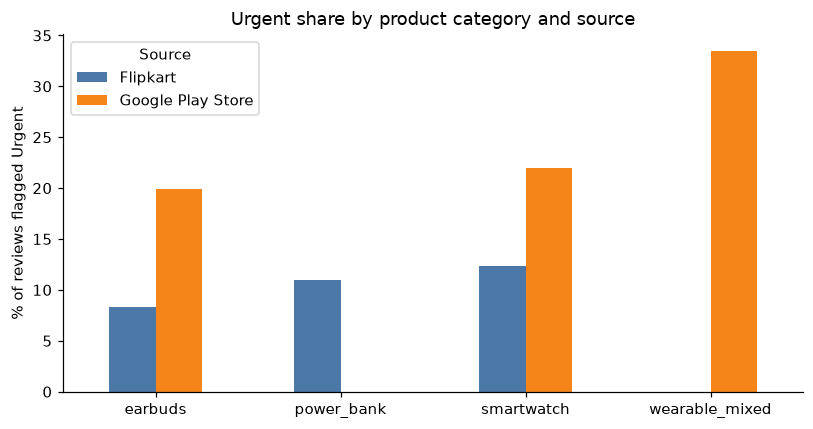

platform_source,Flipkart,Google Play Store
product_category,,
earbuds,8.4,19.9
power_bank,11.0,NaN
smartwatch,12.3,22.0
wearable_mixed,NaN,33.5


In [24]:
# Figure 6: Urgent share by category and source
urg = clean.groupby(["product_category", "platform_source"])["weak_label"].mean().unstack() * 100
ax = urg.plot(kind="bar", figsize=(7.5, 4), color=[C_FLIP, C_PLAY])
ax.set_title("Urgent share by product category and source")
ax.set_xlabel("")
ax.set_ylabel("% of reviews flagged Urgent")
plt.xticks(rotation=0)
plt.legend(title="Source")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_urgent_by_category.png")
plt.show()
urg.round(1)

**Figure 6.** Google Play reviews are flagged Urgent about twice as often as Flipkart reviews, largely because app reviews contain many connection, sync and login failures. The mixed realme Link app has the highest rate. Among Flipkart reviews, the rates for earbuds, power banks and smartwatches are similar, at roughly one review in ten.

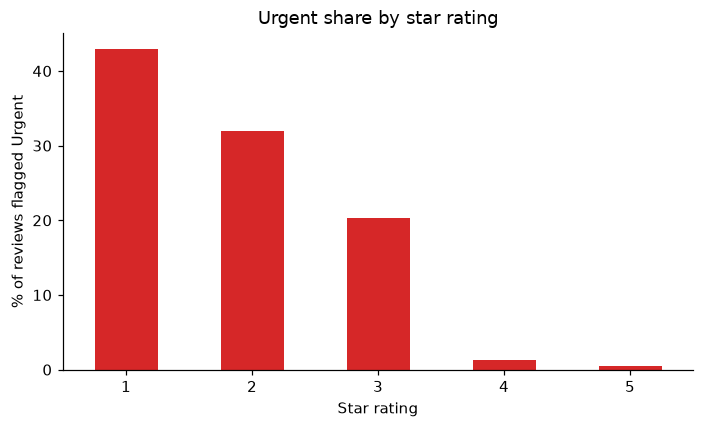

rating
1    42.9
2    32.0
3    20.3
4     1.3
5     0.5
Name: weak_label, dtype: float64

In [25]:
# Figure 7: Urgent share by star rating
by_rating = clean.groupby("rating")["weak_label"].mean() * 100
ax = by_rating.plot(kind="bar", figsize=(6.5, 4), color="#D62728")
ax.set_title("Urgent share by star rating")
ax.set_xlabel("Star rating")
ax.set_ylabel("% of reviews flagged Urgent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_urgent_by_rating.png")
plt.show()
by_rating.round(1)

**Figure 7.** The Urgent share falls sharply as the rating rises, but even 1-star reviews are not all Urgent (many complain about price, features or the interface). That is the business point of the project: **a low rating alone is not a reliable signal of a defect**, so rating-based triage would send many harmless reviews to QA and would miss the ones hidden behind 3-4 stars.

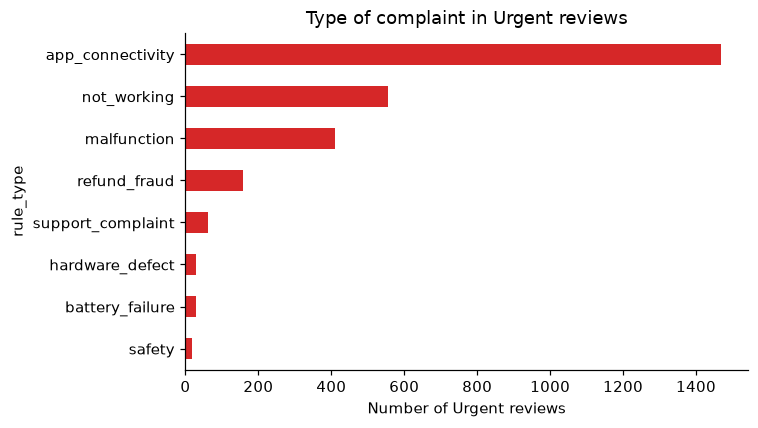

rule_type
app_connectivity     1469
not_working           555
malfunction           409
refund_fraud          159
support_complaint      62
hardware_defect        30
battery_failure        28
safety                 18
Name: count, dtype: int64

In [26]:
# Figure 8: which rule flagged the Urgent reviews
rules_fired = clean.loc[clean["weak_label"] == 1, "rule_type"].value_counts().sort_values()
ax = rules_fired.plot(kind="barh", figsize=(7, 4), color="#D62728")
ax.set_title("Type of complaint in Urgent reviews")
ax.set_xlabel("Number of Urgent reviews")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_rule_types.png")
plt.show()
rules_fired.sort_values(ascending=False)

**Figure 8.** Connection and login problems and general "not working" complaints dominate, followed by outright malfunction. **Safety-type complaints (overheating, swelling, burning) are very rare** (a few dozen reviews at most). This matters for the business conclusion: the value of triage here lies mainly in fast detection of functional failures, while true safety incidents are few but must never be missed.

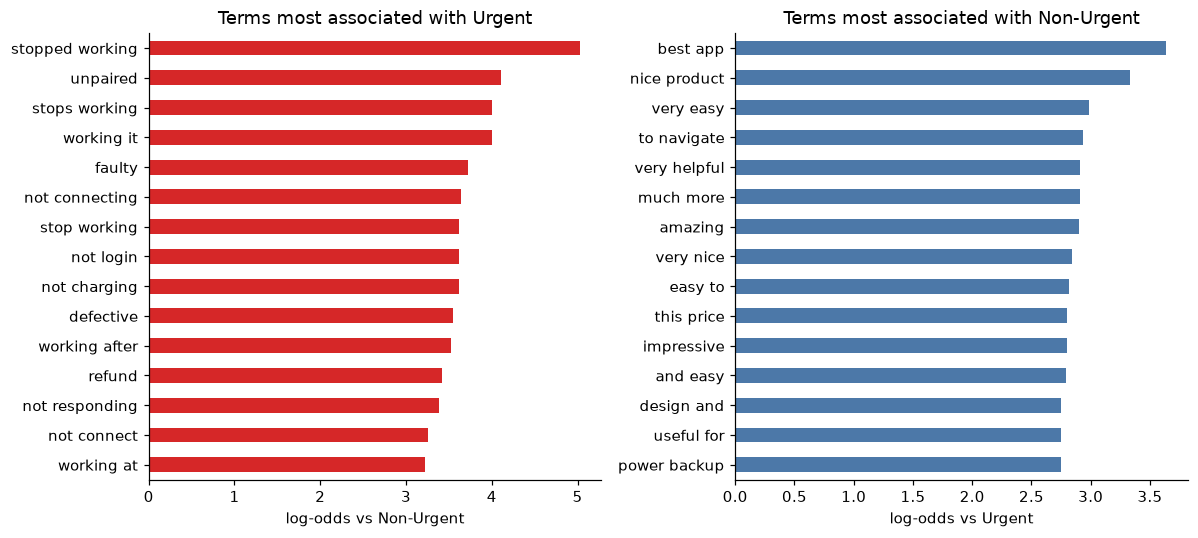

In [27]:
# Figure 9: language most associated with Urgent vs Non-Urgent reviews (log-odds of word/phrase use)
cv = CountVectorizer(ngram_range=(1, 2), min_df=15, binary=True)
X = cv.fit_transform(clean["text_model"])
is_u = (clean["weak_label"] == 1).values
cnt_u = np.asarray(X[is_u].sum(axis=0)).ravel()
cnt_n = np.asarray(X[~is_u].sum(axis=0)).ravel()
V = X.shape[1]
log_odds = np.log((cnt_u + 1) / (cnt_u.sum() + V)) - np.log((cnt_n + 1) / (cnt_n.sum() + V))
scores = pd.Series(log_odds, index=cv.get_feature_names_out()).sort_values(ascending=False)
top_u, top_n = scores.head(15), scores.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
top_u.sort_values().plot(kind="barh", ax=axes[0], color="#D62728")
axes[0].set_title("Terms most associated with Urgent")
axes[0].set_xlabel("log-odds vs Non-Urgent")
(-top_n).sort_values().plot(kind="barh", ax=axes[1], color=C_FLIP)
axes[1].set_title("Terms most associated with Non-Urgent")
axes[1].set_xlabel("log-odds vs Urgent")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig9_top_terms.png")
plt.show()

**Figure 9.** Urgent reviews are marked by failure language ("not working", "not connecting", "stopped", "refund", "login"), while Non-Urgent reviews are marked by praise ("good", "nice", "love", "great"). Because the labels come from keyword rules, this chart partly reproduces the rules, so it is treated as a description of the labeled data and not as a discovery. The model coefficients in Section 4 give the real term analysis.

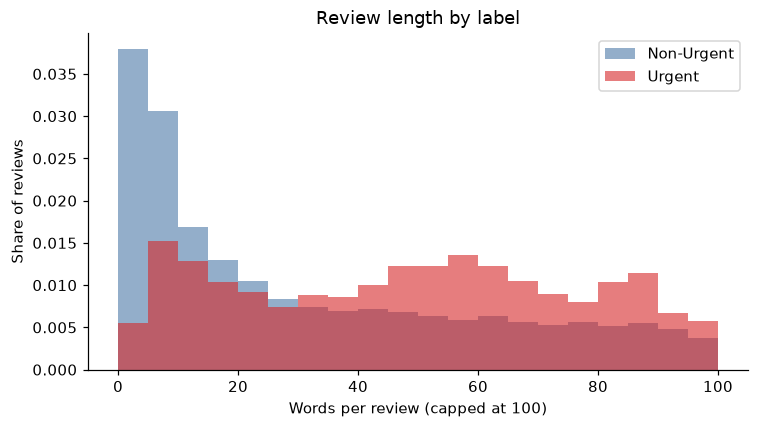

weak_label
Non-Urgent    20.0
Urgent        49.0
Name: word_count, dtype: float64

In [28]:
# Figure 10: review length by label
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, 105, 5)
for lab, name, colour in [(0, "Non-Urgent", C_FLIP), (1, "Urgent", "#D62728")]:
    w = clean.loc[clean["weak_label"] == lab, "word_count"].clip(upper=100)
    ax.hist(w, bins=bins, alpha=0.6, density=True, label=name, color=colour)
ax.set_title("Review length by label")
ax.set_xlabel("Words per review (capped at 100)")
ax.set_ylabel("Share of reviews")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig10_length_by_label.png")
plt.show()
clean.groupby("weak_label")["word_count"].median().rename({0: "Non-Urgent", 1: "Urgent"})

**Figure 10.** Urgent reviews are longer than Non-Urgent ones. People describe a failure in detail, while praise is usually a few words. Length is therefore a weak signal, but it also means very short reviews are hard to classify as Urgent.

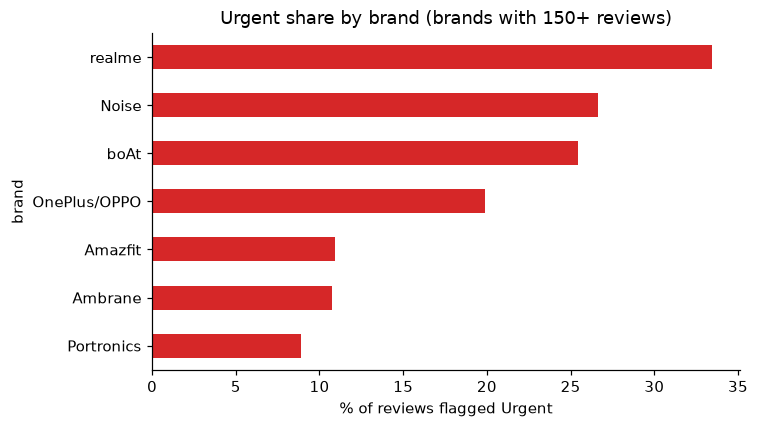

,urgent_%,count
brand,,
realme,33.5,1967
Noise,26.7,2386
boAt,25.5,2600
OnePlus/OPPO,19.9,2208
Amazfit,10.9,2337
Ambrane,10.7,177
Portronics,8.9,303


In [29]:
# Figure 11: Urgent share by brand (brands with at least 150 reviews)
brand_urg = clean.groupby("brand")["weak_label"].agg(["mean", "count"])
brand_urg = brand_urg[brand_urg["count"] >= 150].sort_values("mean")
ax = (brand_urg["mean"] * 100).plot(kind="barh", figsize=(7, 4), color="#D62728")
ax.set_title("Urgent share by brand (brands with 150+ reviews)")
ax.set_xlabel("% of reviews flagged Urgent")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_urgent_by_brand.png")
plt.show()
brand_urg.assign(mean=(brand_urg["mean"] * 100).round(1)).rename(columns={"mean": "urgent_%"}).sort_values("urgent_%", ascending=False)

**Figure 11.** Brand differences here mix two things: the quality of the device and the quality of its companion app, because most of these reviews are app reviews. These differences are interpreted as differences in *complaint patterns*, not as a ranking of product quality.

## 3.9 Train / test split and final dataset

The split protects the honesty of the evaluation:

| Split | Used for | Labels |
|---|---|---|
| `train` | Training the model | Rule-based labels (all reviews outside the gold sample) |
| `gold_dev` | Tuning the model and the rules | Human labels |
| `gold_test` | Final evaluation, touched once | Human labels |
| `gold_unlabeled` | Reviews in the gold sample that were not labeled; excluded from training to prevent leakage | none |

If the gold labels are not available yet, a temporary stratified 80/20 split on the rule-based labels is created (`train` / `test_weak`). That temporary split is only for checking the code; the report uses the gold-based split.

In [30]:
if GOLD_READY:
    in_sample = set(meta["review_id"])
    dev_ids = set(gold.loc[gold["gold_split"] == "dev", "review_id"])
    test_ids = set(gold.loc[gold["gold_split"] == "test", "review_id"])
    clean["split"] = "train"
    clean.loc[clean["review_id"].isin(in_sample), "split"] = "gold_unlabeled"
    clean.loc[clean["review_id"].isin(dev_ids), "split"] = "gold_dev"
    clean.loc[clean["review_id"].isin(test_ids), "split"] = "gold_test"
    final = clean.drop(columns=["gold_label"], errors="ignore").merge(
        gold[["review_id", "gold_label"]], on="review_id", how="left")
else:
    strat = clean["weak_label"].astype(str) + "|" + clean["platform_source"]
    _, te = train_test_split(clean["review_id"], test_size=0.2, stratify=strat, random_state=SEED)
    clean["split"] = np.where(clean["review_id"].isin(set(te)), "test_weak", "train")
    final = clean.drop(columns=["gold_label"], errors="ignore").copy()
    final["gold_label"] = np.nan
    print("Gold labels not available: using the TEMPORARY weak-label split.")

split_table = final.groupby("split").agg(
    reviews=("review_id", "count"),
    urgent_rule_pct=("weak_label", lambda s: round(s.mean() * 100, 1)),
    urgent_human_pct=("gold_label", lambda s: round(s.mean() * 100, 1) if s.notna().any() else np.nan),
)
split_table

,reviews,urgent_rule_pct,urgent_human_pct
split,,,
gold_dev,280,21.4,16.8
gold_test,420,22.6,20.0
train,11749,21.9,NaN


In [31]:
# Save the final analysis dataset (this is the file used for modeling in Section 4)
out_cols = ["review_id", "review_text", "text_model", "rating", "review_date", "date_approx",
            "platform_source", "source_type", "product_category", "brand", "product_name",
            "helpful_votes", "certified_buyer", "word_count", "weak_label", "rule_type", "gold_label", "split"]
final[out_cols].to_csv(CLEAN_DIR / "reviews_labeled.csv", index=False, encoding="utf-8")
print("Saved:", CLEAN_DIR / "reviews_labeled.csv", f"({len(final):,} rows)")

summary = {
    "Raw records": len(raw),
    "Clean records": len(final),
    "Urgent share (rules)": f"{final['weak_label'].mean():.1%}",
    "Urgent share, Flipkart / Google Play": " / ".join(
        f"{final.loc[final['platform_source'] == s, 'weak_label'].mean():.1%}" for s in ["Flipkart", "Google Play Store"]),
    "Gold sample labeled": int(gold["gold_label"].notna().sum()) if GOLD_READY else "not yet",
    "Rules vs human, TEST kappa": round(agreement["test"]["kappa"], 2) if "test" in agreement else "n/a",
    "Rules vs human, TEST recall": round(agreement["test"]["recall"], 2) if "test" in agreement else "n/a",
    "Rules vs human, TEST precision": round(agreement["test"]["precision"], 2) if "test" in agreement else "n/a",
}
print()
for k, v in summary.items():
    print(f"{k:40s} {v}")

Saved: c:\Users\saiva\Downloads\DefectSignal_Submission\data\clean\reviews_labeled.csv (12,449 rows)

Raw records                              16768
Clean records                            12449
Urgent share (rules)                     21.9%
Urgent share, Flipkart / Google Play     10.6% / 23.6%
Gold sample labeled                      700
Rules vs human, TEST kappa               0.5
Rules vs human, TEST recall              0.65
Rules vs human, TEST precision           0.58


## Section 4: Method and Implementation

TF-IDF features feed two classifiers, **Logistic Regression** and **Multinomial Naive Bayes**. The model is trained on the `train` split (rule-based labels), tuned on `gold_dev` (280 human-labeled reviews) and evaluated once on `gold_test` (420 human-labeled reviews, not inspected before now).

**Why recall on the Urgent class matters most here:** missing a real defect (a false Non-Urgent) lets a safety or malfunction complaint go unnoticed, which is the exact problem this project exists to prevent. A false alarm (a harmless review flagged Urgent) only costs a QA team a few minutes of review. So model selection below favours **Urgent-class recall and F1** over overall accuracy, and both models use class weighting to counter the roughly 4-to-1 Non-Urgent-to-Urgent imbalance.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score, precision_recall_curve)

labeled = pd.read_csv(CLEAN_DIR / "reviews_labeled.csv")
labeled["text_model"] = labeled["text_model"].fillna("")

train = labeled[labeled["split"] == "train"]
dev = labeled[labeled["split"] == "gold_dev"].dropna(subset=["gold_label"])
test = labeled[labeled["split"] == "gold_test"].dropna(subset=["gold_label"])

X_train_text, y_train = train["text_model"], train["weak_label"].astype(int)
X_dev_text, y_dev = dev["text_model"], dev["gold_label"].astype(int)
X_test_text, y_test = test["text_model"], test["gold_label"].astype(int)

print(f"Train: {len(train):,} reviews (rule-based labels, {y_train.mean():.1%} Urgent)")
print(f"Dev:   {len(dev):,} reviews (human labels, {y_dev.mean():.1%} Urgent) - used to choose the model")
print(f"Test:  {len(test):,} reviews (human labels, {y_test.mean():.1%} Urgent) - touched once, at the end")

Train: 11,749 reviews (rule-based labels, 21.9% Urgent)
Dev:   280 reviews (human labels, 16.8% Urgent) - used to choose the model
Test:  420 reviews (human labels, 20.0% Urgent) - touched once, at the end


### 4.1 TF-IDF features

Unigrams and bigrams, English stop words removed (unlike the labeling step, common words carry less useful signal once weighted by TF-IDF), terms appearing in at least 5 reviews, and a 20,000-term cap. The vectorizer is fit on the **training split only**; the dev and test sets are transformed with that same vocabulary, so no information from the evaluation sets leaks into the features.

In [33]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=20_000, stop_words="english")
X_train = tfidf.fit_transform(X_train_text)
X_dev = tfidf.transform(X_dev_text)
X_test = tfidf.transform(X_test_text)

print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"Train matrix: {X_train.shape}, Dev matrix: {X_dev.shape}, Test matrix: {X_test.shape}")

Vocabulary size: 7,529
Train matrix: (11749, 7529), Dev matrix: (280, 7529), Test matrix: (420, 7529)


### 4.2 Train the two models

Both use `class_weight="balanced"` (Logistic Regression natively; Naive Bayes via `sample_weight`, since `MultinomialNB` has no `class_weight` parameter) so the models are not biased toward the majority Non-Urgent class.

In [34]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0, random_state=SEED)
log_reg.fit(X_train, y_train)

nb = MultinomialNB(alpha=0.5)
sample_weight = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1.0)
nb.fit(X_train, y_train, sample_weight=sample_weight)

print("Both models trained.")

Both models trained.


### 4.3 Model selection on the DEV split

Both models are compared on `gold_dev`. The better one (by Urgent-class F1) is carried forward; its threshold and regularisation are not re-tuned any further after this point.

In [35]:
def evaluate(model, X, y, name):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    prec, rec, f1, _ = precision_recall_fscore_support(y, pred, average="binary", pos_label=1, zero_division=0)
    acc = (pred == y).mean()
    auc = roc_auc_score(y, proba)
    ap = average_precision_score(y, proba)
    print(f"{name:20s} acc={acc:.3f}  Urgent: precision={prec:.3f} recall={rec:.3f} f1={f1:.3f}  "
          f"ROC-AUC={auc:.3f}  PR-AUC={ap:.3f}")
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc, "pr_auc": ap}


print("--- DEV split (model selection) ---")
dev_results = [
    evaluate(log_reg, X_dev, y_dev, "Logistic Regression"),
    evaluate(nb, X_dev, y_dev, "Naive Bayes"),
]
dev_table = pd.DataFrame(dev_results).set_index("model").round(3)
dev_table

--- DEV split (model selection) ---
Logistic Regression  acc=0.807  Urgent: precision=0.446 recall=0.617 f1=0.518  ROC-AUC=0.863  PR-AUC=0.517
Naive Bayes          acc=0.771  Urgent: precision=0.411 recall=0.830 f1=0.549  ROC-AUC=0.845  PR-AUC=0.531


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.807,0.446,0.617,0.518,0.863,0.517
Naive Bayes,0.771,0.411,0.830,0.549,0.845,0.531


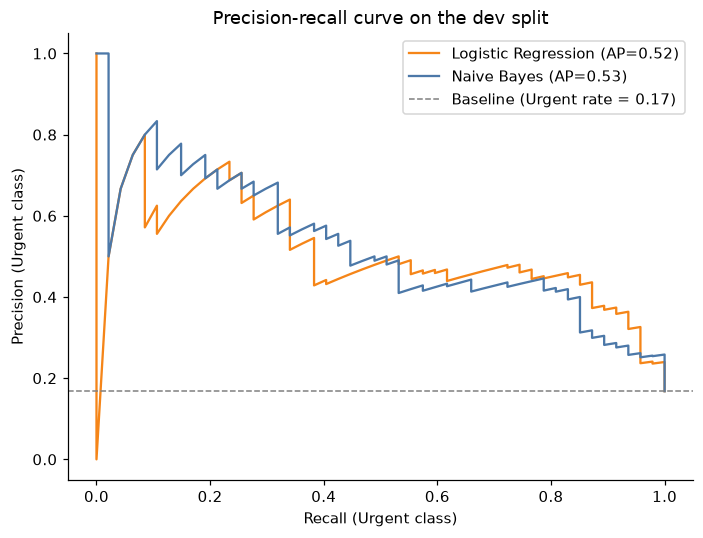

In [36]:
# Figure 12: precision-recall curves on the dev split (threshold-independent comparison)
fig, ax = plt.subplots(figsize=(6.5, 5))
for model, name, colour in [(log_reg, "Logistic Regression", C_PLAY), (nb, "Naive Bayes", C_FLIP)]:
    p, r, _ = precision_recall_curve(y_dev, model.predict_proba(X_dev)[:, 1])
    ax.plot(r, p, label=f"{name} (AP={average_precision_score(y_dev, model.predict_proba(X_dev)[:, 1]):.2f})",
            color=colour)
ax.axhline(y_dev.mean(), color="grey", linestyle="--", linewidth=1, label=f"Baseline (Urgent rate = {y_dev.mean():.2f})")
ax.set_xlabel("Recall (Urgent class)")
ax.set_ylabel("Precision (Urgent class)")
ax.set_title("Precision-recall curve on the dev split")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig12_pr_curve_dev.png")
plt.show()

In [37]:
BEST_MODEL_NAME = dev_table["f1"].idxmax()
best_model = log_reg if BEST_MODEL_NAME == "Logistic Regression" else nb
print(f"Selected model (best Urgent-class F1 on DEV): {BEST_MODEL_NAME}")

Selected model (best Urgent-class F1 on DEV): Naive Bayes


### 4.4 Final evaluation on the TEST split

This is the one and only look at `gold_test`. Both models are still reported here for transparency and for the comparison table in the report, but the **selected model's TEST numbers are the ones to quote as the project's headline result.**

In [38]:
print("--- TEST split (final, one-time evaluation) ---")
test_results = [
    evaluate(log_reg, X_test, y_test, "Logistic Regression"),
    evaluate(nb, X_test, y_test, "Naive Bayes"),
]
test_table = pd.DataFrame(test_results).set_index("model").round(3)
test_table

--- TEST split (final, one-time evaluation) ---
Logistic Regression  acc=0.810  Urgent: precision=0.517 recall=0.738 f1=0.608  ROC-AUC=0.876  PR-AUC=0.616
Naive Bayes          acc=0.781  Urgent: precision=0.473 recall=0.845 f1=0.607  ROC-AUC=0.880  PR-AUC=0.656


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.810,0.517,0.738,0.608,0.876,0.616
Naive Bayes,0.781,0.473,0.845,0.607,0.880,0.656


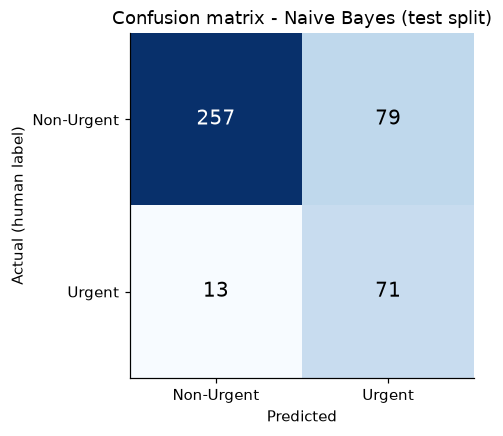

              precision    recall  f1-score   support

  Non-Urgent      0.952     0.765     0.848       336
      Urgent      0.473     0.845     0.607        84

    accuracy                          0.781       420
   macro avg      0.713     0.805     0.728       420
weighted avg      0.856     0.781     0.800       420



In [39]:
# Figure 13: confusion matrix for the selected model on the test split
pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Non-Urgent", "Urgent"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Non-Urgent", "Urgent"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual (human label)")
ax.set_title(f"Confusion matrix - {BEST_MODEL_NAME} (test split)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig13_confusion_matrix.png")
plt.show()
print(classification_report(y_test, pred_best, target_names=["Non-Urgent", "Urgent"], digits=3))

**How to read the confusion matrix.** The bottom-left cell (actual Urgent, predicted Non-Urgent) is the costly error: a real defect complaint the model would have let slip past QA. The top-right cell (actual Non-Urgent, predicted Urgent) is the cheap error: a harmless review that gets an extra minute of review. Both counts are reported in Section 6, since the business case set out in the objectives rests on keeping the first number low.

In [40]:
# Model comparison table for the report (dev = selection, test = final honest numbers)
comparison = pd.concat([dev_table.add_suffix("_dev"), test_table.add_suffix("_test")], axis=1)
comparison = comparison[[c for c in comparison.columns if c.startswith(("precision", "recall", "f1", "accuracy"))]]
comparison

,accuracy_dev,precision_dev,recall_dev,f1_dev,accuracy_test,precision_test,recall_test,f1_test
model,,,,,,,,
Logistic Regression,0.807,0.446,0.617,0.518,0.810,0.517,0.738,0.608
Naive Bayes,0.771,0.411,0.830,0.549,0.781,0.473,0.845,0.607


### 4.5 What the model learned: top terms per class

Only Logistic Regression gives directly interpretable coefficients (Naive Bayes' log-probabilities are shown for comparison but are less directly interpretable as "importance"). These charts serve Objective 2: recurring language patterns associated with urgent complaints, this time learned from the model rather than assumed by the keyword rules.

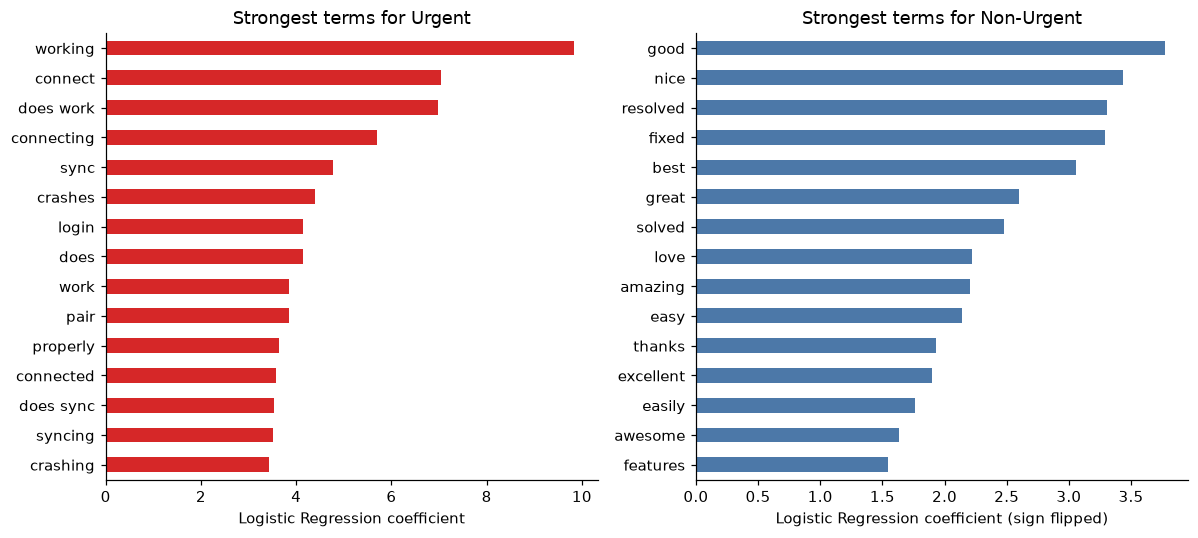

In [41]:
# Figure 14: strongest Logistic Regression coefficients for each class
feature_names = np.array(tfidf.get_feature_names_out())
coefs = log_reg.coef_[0]
order = np.argsort(coefs)
top_non_urgent = pd.Series(coefs[order[:15]], index=feature_names[order[:15]])
top_urgent = pd.Series(coefs[order[-15:]], index=feature_names[order[-15:]])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
top_urgent.sort_values().plot(kind="barh", ax=axes[0], color="#D62728")
axes[0].set_title("Strongest terms for Urgent")
axes[0].set_xlabel("Logistic Regression coefficient")
(-top_non_urgent).sort_values().plot(kind="barh", ax=axes[1], color=C_FLIP)
axes[1].set_title("Strongest terms for Non-Urgent")
axes[1].set_xlabel("Logistic Regression coefficient (sign flipped)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig14_top_coefficients.png")
plt.show()

### 4.6 Error analysis on the test split

A close look at where the selected model disagrees with the human labels, useful for the report's discussion of limitations.

In [42]:
test_out = test.copy()
test_out["predicted"] = pred_best
test_out["predicted_proba"] = best_model.predict_proba(X_test)[:, 1]

fn = test_out[(test_out["gold_label"] == 1) & (test_out["predicted"] == 0)]
fp = test_out[(test_out["gold_label"] == 0) & (test_out["predicted"] == 1)]
pd.set_option("display.max_colwidth", 200)
print(f"Missed Urgent reviews (false negatives): {len(fn)} of {int(y_test.sum())} actual Urgent reviews")
print(fn.sort_values("predicted_proba")[["review_text", "predicted_proba"]].head(10).to_string())
print(f"\nFalse alarms (false positives): {len(fp)}")
print(fp.sort_values("predicted_proba", ascending=False)[["review_text", "predicted_proba"]].head(10).to_string())

Missed Urgent reviews (false negatives): 13 of 84 actual Urgent reviews
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             review_text  predicted_proba
11160  This app works very well; does not crash on my phone (Redmi note 11) unlike others like Samsung wearable. Sound & touch control in the app works great. However, it would be better if there would be preset equalizer & sound mode to select according to the environment. I.e. when travelling in bus, train, airplane or just in a private room or in a room with lots of people etc, if an preset settings 

In [43]:
# Save the final model artifacts and predictions for Section 5/6
import pickle

MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
with open(MODEL_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)
with open(MODEL_DIR / "logistic_regression.pkl", "wb") as f:
    pickle.dump(log_reg, f)
with open(MODEL_DIR / "naive_bayes.pkl", "wb") as f:
    pickle.dump(nb, f)

test_out.drop(columns=["text_model"]).to_csv(CLEAN_DIR / "test_predictions.csv", index=False)
comparison.to_csv(CLEAN_DIR / "model_comparison.csv")

print("Selected model:", BEST_MODEL_NAME)
print("Saved model files to:", MODEL_DIR)
print("Saved test predictions to:", CLEAN_DIR / "test_predictions.csv")
print("\nFINAL HEADLINE RESULT (test split, human labels):")
print(test_table.loc[BEST_MODEL_NAME])

Selected model: Naive Bayes
Saved model files to: c:\Users\saiva\Downloads\DefectSignal_Submission\models
Saved test predictions to: c:\Users\saiva\Downloads\DefectSignal_Submission\data\clean\test_predictions.csv

FINAL HEADLINE RESULT (test split, human labels):
accuracy     0.781
precision    0.473
recall       0.845
f1           0.607
roc_auc      0.880
pr_auc       0.656
Name: Naive Bayes, dtype: float64
